**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 4**
Exploración de datos

---

*   NOMBRE: Mónica María Ramírez Mejía
*   MATRÍCULA: A01797493

En esta actividad trabajarás con el archivo `personal_loan.csv`, basado en un conjunto de datos sobre clientes bancarios y su comportamiento financiero disponible en Kaggle.

Los datos fueron recopilados para analizar la posibilidad de que los clientes acepten un préstamo personal y contienen información demográfica, financiera y de productos bancarios asociados. Los indicadores incluidos son:

* `ID`: Identificador único del cliente
* `Age`: Edad del cliente (años completos)
* `Experience`: Experiencia laboral en años
* `Income`: Ingreso anual del cliente (en miles de dólares. Por ejemplo, 60 = 60,000 USD/año)
* `ZIP Code`: Código postal del cliente
* `Family`: Número de miembros de la familia
* `CCAvg`: Promedio de gastos mensuales con tarjeta de crédito (en miles de dólares)
* `Education`: Nivel educativo (1 = graduado, 2 = universitario, 3 = posgrado)
* `Mortgage`: Monto de hipoteca que posee el cliente (en miles de dólares)
* `Securities Account`: Indicador de si tiene cuenta de valores (1 = sí, 0 = no)
* `CD Account`: Indicador de si tiene cuenta de certificado de depósito (1 = sí, 0 = no)
* `Online`: Indicador de si usa los servicios bancarios en línea (1 = sí, 0 = no)
* `CreditCard`: Indicador de si es titular de tarjeta de crédito (1 = sí, 0 = no)
* `Personal Loan`: Si el cliente aceptó (1) o no (0) un préstamo personal. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [2242]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

1. Descarga el archivo: `personal_loan.csv` y guarda, en un dataframe (`loan_df`), todos sus registros.
* Haz que la columna `ID` sea el índice del dataframe.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?

In [2243]:
from google.colab import drive
drive.mount('/content/drive')
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/Ciencia y Analitica de Datos/Tareas/Semana4"
os.chdir(DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2244]:
# importar dataframe
loan_df = pd.read_csv('personal_loan.csv')

In [2245]:
loan_df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,0,25,1,49,91108,4,1.6,1.0,0,0,Yes,No,0,0
1,1,45,19,34,90089,3,1.5,1.0,0,No,Yes,No,No,0
2,2,39,15,11,94720,1,1.0,1.0,0,0,0,0,0,0
3,3,35,9,100,94112,1,2.7,2.0,0,0,0,0,No,0
4,4,35,8,45,91330,4,1.0,2.0,0,0,No,No,0,1


In [2246]:
# id como indice
loan_df.set_index('ID', inplace=True)

In [2247]:
loan_df.shape

(5037, 13)

In [2248]:
loan_df.head(5)

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
0,25,1,49,91108,4,1.6,1.0,0,0,Yes,No,0,0
1,45,19,34,90089,3,1.5,1.0,0,No,Yes,No,No,0
2,39,15,11,94720,1,1.0,1.0,0,0,0,0,0,0
3,35,9,100,94112,1,2.7,2.0,0,0,0,0,No,0
4,35,8,45,91330,4,1.0,2.0,0,0,No,No,0,1


In [2249]:
loan_df.tail(5)

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
5032,34,9,65,95134,4,1.3,1.0,0,0,No,No,No,Yes
5033,45,20,84,94131,4,1.1,2.0,180,0,No,0,1,0
5034,47,23,148,94551,2,7.5,1.0,0,0,No,1,Yes,Yes
5035,56,32,58,95064,1,1.8,3.0,241,0,No,No,Yes,0
5036,52,26,194,94305,1,1.7,1.0,0,0,0,No,Yes,0


In [2250]:
# resumen de los datos con info ()
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5037 entries, 0 to 5036
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5037 non-null   int64  
 1   Experience          5037 non-null   int64  
 2   Income              5037 non-null   int64  
 3   ZIP Code            5037 non-null   int64  
 4   Family              5037 non-null   int64  
 5   CCAvg               5037 non-null   float64
 6   Education           5037 non-null   float64
 7   Mortgage            5037 non-null   int64  
 8   Personal Loan       5037 non-null   object 
 9   Securities Account  5037 non-null   object 
 10  CD Account          5037 non-null   object 
 11  Online              5037 non-null   object 
 12  CreditCard          5037 non-null   object 
dtypes: float64(2), int64(6), object(5)
memory usage: 550.9+ KB


Son 5 columnas de texto y 8 numericas (6 int y 2 float)

# Limpieza

2. Obtén las estadísticas descriptivas de las variables numéricas y examina cuidadosamente los valores obtenidos de cada columna.
* Filtra el dataframe para visualizar los registros en que la edad supera los 100 años y elimínalos si no son pausibles.
* Analiza el resto de las variables y elimina aquellos registros que contengan valores inválidos o inconsistentes. Para cada acción que realices, justifica la decisión, explicando por qué consideras que el valor es incorrecto.
* ¿Cuántos registros se eliminaron (considerando todas las acciones de este ejercicio) y qué porcentaje representa respecto al total del dataframe inicial?

In [2251]:
#filtrar los registros de edad >100
loan_df[loan_df['Age'] > 100]['Age'].value_counts()

,count
Age,
123,1
144,1
130,1


<Axes: >

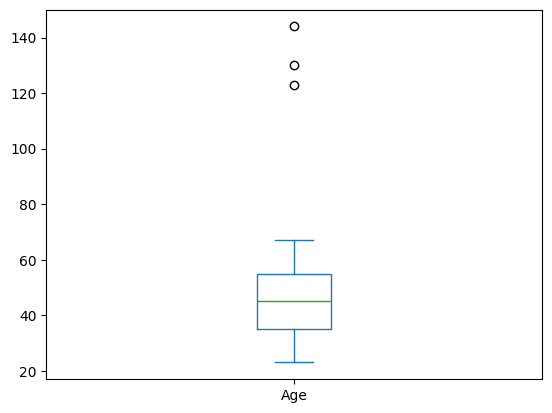

In [2252]:
loan_df['Age'].plot.box()

In [2253]:
#eliminar los registros outliers
loan_df.loc[loan_df['Age'].isin([123,144,130])]

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
10,123,39,105,94710,4,2.4,3.0,0,0,0,0,No,0
250,144,6,29,94305,3,1.0,2.0,117,0,No,0,No,No
4800,130,7,73,94028,1,2.5,1.0,135,0,No,0,0,0


In [2254]:
loan_df.drop(index = [10,250,4800], inplace= True)

<Axes: >

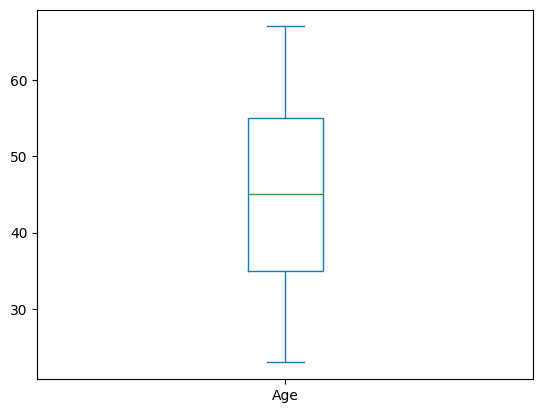

In [2255]:
loan_df['Age'].plot.box()

In [2256]:
loan_df.shape

(5034, 13)

In [2257]:
#analizar las otras variables
loan_df.nunique()

,0
Age,45
Experience,47
Income,162
ZIP Code,468
Family,6
CCAvg,108
Education,4
Mortgage,347
Personal Loan,4
Securities Account,4


In [2258]:
loan_df.isna().sum()
#no contiene valores nulos

,0
Age,0
Experience,0
Income,0
ZIP Code,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal Loan,0
Securities Account,0


In [2259]:
loan_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5034.0,45.359555,11.453265,23.0,35.0,45.0,55.0,67.0
Experience,5034.0,20.124156,11.458383,-3.0,10.0,20.0,30.0,43.0
Income,5034.0,73.901271,46.137826,8.0,39.0,64.0,98.0,224.0
ZIP Code,5034.0,93152.153556,2120.057771,9307.0,91911.0,93437.0,94608.0,96651.0
Family,5034.0,2.394517,1.151066,-3.0,1.0,2.0,3.0,4.0
CCAvg,5034.0,1.942390,1.756398,0.0,0.7,1.5,2.6,10.0
Education,5034.0,1.880870,0.843348,1.0,1.0,2.0,3.0,7.3
Mortgage,5034.0,56.484307,101.675156,0.0,0.0,0.0,101.0,635.0


In [2260]:
loan_df.describe(include = 'object').T

,count,unique,top,freq
Personal Loan,5034,4,0,3517
Securities Account,5034,4,No,2724
CD Account,5034,4,No,2482
Online,5034,4,Yes,1718
CreditCard,5034,4,0,2652


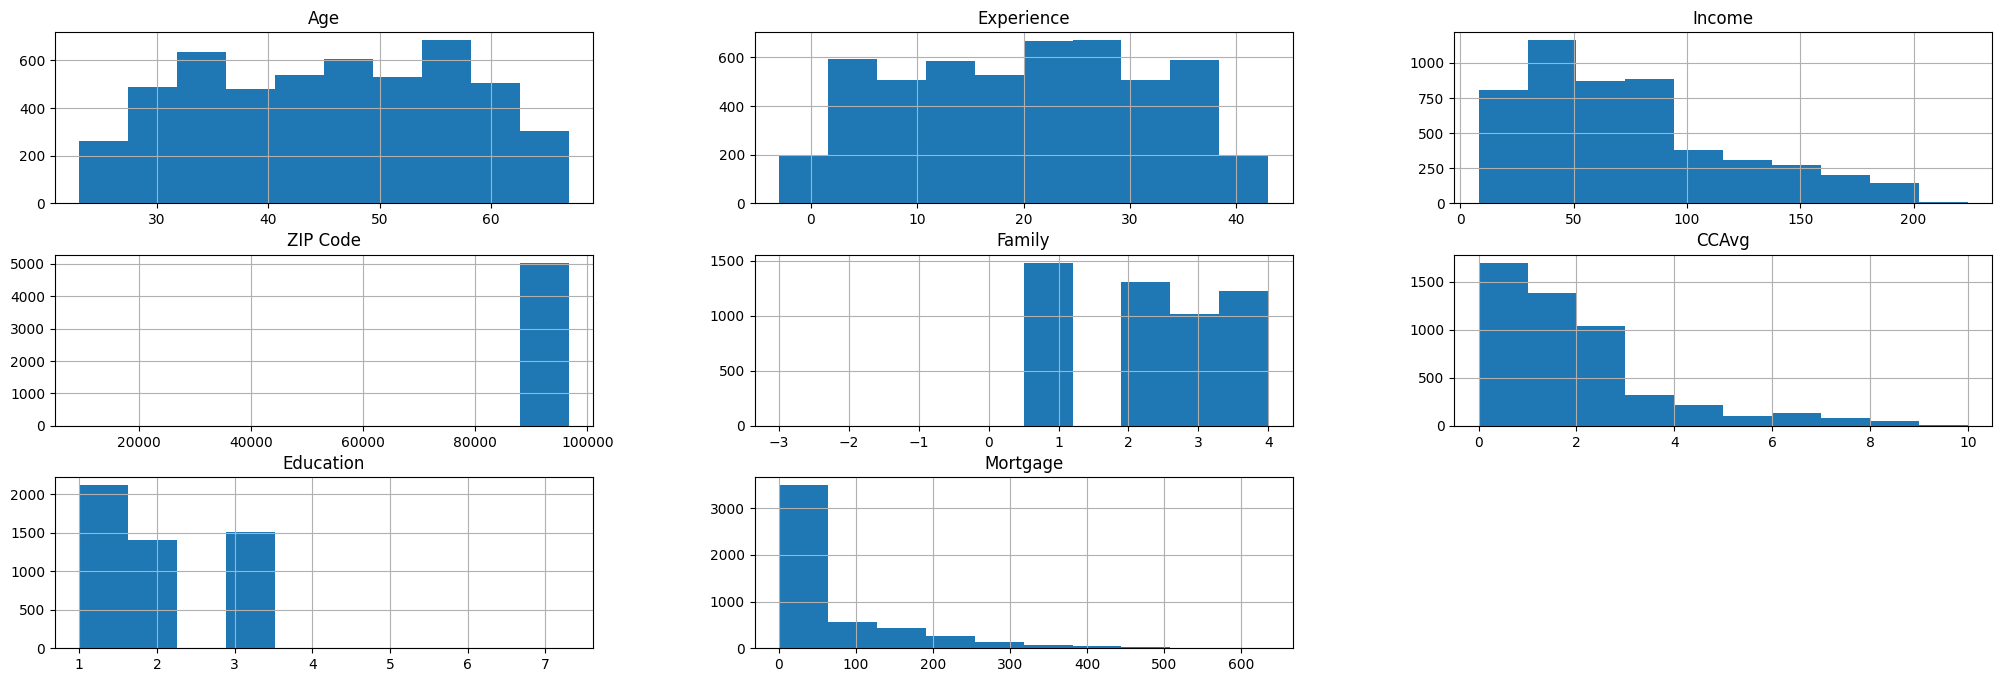

In [2261]:
#analisis visual de todas las variables que estan identificadas como int
#ZIP Code parece estar mal clasificada, es una variable categorica
loan_df.hist(figsize=(25,8))
plt.show()

In [2262]:
loan_df['Experience'].value_counts().sort_index(ascending=True)

,count
Experience,
-3,4
-2,15
-1,34
0,66
1,75
2,85
3,129
4,113
5,147


In [2263]:
(loan_df['Experience'].isin([-3, -2, -1])).sum()

np.int64(53)

In [2264]:
#eliminar experiencia <0 porque no tiene sentido en el contexto de la variable, una persona no puede tener -x cantidad de años de experiencia laboral
loan_df.drop(loan_df[loan_df['Experience'] < 0].index, inplace=True)

In [2265]:
#eliminar 1 registro de Education, porque segun las variables solo es posible que contenga los valores 1, 2, 3
loan_df['Education'].value_counts().sort_index(ascending=True)

,count
Education,
1.0,2098
2.0,1394
3.0,1488
7.3,1


In [2266]:
loan_df.loc[loan_df['Education'].isin([7.3])]

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
347,25,0,43,94305,2,1.6,7.3,0,0,Yes,Yes,1,Yes


In [2267]:
loan_df.drop(index = [347], inplace= True)

In [2268]:
#eliminar 2 registros negativos porque no hacen sentido con la variable
loan_df['Family'].value_counts()


,count
Family,
1,1480
2,1281
4,1211
3,1006
-1,1
-3,1


In [2269]:
loan_df.loc[loan_df['Family'].isin([-1, -3])]

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
15,60,30,22,95054,-1,1.5,3.0,0,0,No,0,Yes,Yes
3000,40,14,164,94720,-3,4.3,2.0,0,1,No,No,No,No


In [2270]:
loan_df.drop(index = [15, 3000], inplace= True)

In [2271]:
loan_df.shape

(4978, 13)

In [2272]:
#se eliminaron, tomando en cuenta los de Age y de Experience
num_eliminados = 5037 - len(loan_df)
num_eliminados
porc_eliminados = (num_eliminados/5037)*100
porc_eliminados
print('registros eliminados = ', num_eliminados, '            ', 'porcentaje de registros eliminados = ', porc_eliminados, '%')

registros eliminados =  59              porcentaje de registros eliminados =  1.171332142148104 %


3. Obtén las estadísticas descriptivas de las variables de texto e imprime las frecuencias de sus categorías.
* Algunas columnas almacenan valores binarios utilizando distintos formatos. Unifica estos valores de manera consistente, asegurándote de que coincidan con la descripción de las variables al inicio de esta libreta.

In [2273]:
loan_df.describe(include = 'object').T

,count,unique,top,freq
Personal Loan,4978,4,0,3475
Securities Account,4978,4,No,2693
CD Account,4978,4,No,2462
Online,4978,4,Yes,1700
CreditCard,4978,4,0,2628


In [2274]:
print(loan_df['Personal Loan'].value_counts())
print(loan_df['Securities Account'].value_counts())
print(loan_df['CD Account'].value_counts())
print(loan_df['Online'].value_counts())
print(loan_df['CreditCard'].value_counts())

Personal Loan
0      3475
No     1018
Yes     368
1       117
Name: count, dtype: int64
Securities Account
No     2693
0      1766
Yes     390
1       129
Name: count, dtype: int64
CD Account
No     2462
0      2213
1       163
Yes     140
Name: count, dtype: int64
Online
Yes    1700
No     1628
1      1276
0       374
Name: count, dtype: int64
CreditCard
0      2628
Yes     908
No      885
1       557
Name: count, dtype: int64


In [2275]:
loan_df.loc[loan_df['Personal Loan'] == 'No', 'Personal Loan'] = '0'
loan_df.loc[loan_df['Personal Loan'] == 'Yes', 'Personal Loan'] = '1'
print(loan_df['Personal Loan'].value_counts())

Personal Loan
0    4493
1     485
Name: count, dtype: int64


In [2276]:
loan_df.loc[loan_df['Securities Account'] == 'No', 'Securities Account'] = '0'
loan_df.loc[loan_df['Securities Account'] == 'Yes', 'Securities Account'] = '1'
print(loan_df['Securities Account'].value_counts())

Securities Account
0    4459
1     519
Name: count, dtype: int64


In [2277]:
loan_df.loc[loan_df['CD Account'] == 'No', 'CD Account'] = '0'
loan_df.loc[loan_df['CD Account'] == 'Yes', 'CD Account'] = '1'
print(loan_df['CD Account'].value_counts())

CD Account
0    4675
1     303
Name: count, dtype: int64


In [2278]:
loan_df.loc[loan_df['Online'] == 'No', 'Online'] = '0'
loan_df.loc[loan_df['Online'] == 'Yes', 'Online'] = '1'
print(loan_df['Online'].value_counts())

Online
1    2976
0    2002
Name: count, dtype: int64


In [2279]:
loan_df.loc[loan_df['CreditCard'] == 'No', 'CreditCard'] = '0'
loan_df.loc[loan_df['CreditCard'] == 'Yes', 'CreditCard'] = '1'
print(loan_df['CreditCard'].value_counts())

CreditCard
0    3513
1    1465
Name: count, dtype: int64


In [2280]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4978 entries, 0 to 5036
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 4978 non-null   int64  
 1   Experience          4978 non-null   int64  
 2   Income              4978 non-null   int64  
 3   ZIP Code            4978 non-null   int64  
 4   Family              4978 non-null   int64  
 5   CCAvg               4978 non-null   float64
 6   Education           4978 non-null   float64
 7   Mortgage            4978 non-null   int64  
 8   Personal Loan       4978 non-null   object 
 9   Securities Account  4978 non-null   object 
 10  CD Account          4978 non-null   object 
 11  Online              4978 non-null   object 
 12  CreditCard          4978 non-null   object 
dtypes: float64(2), int64(6), object(5)
memory usage: 544.5+ KB


In [2281]:
loan_df.describe(include = 'object').T

,count,unique,top,freq
Personal Loan,4978,2,0,4493
Securities Account,4978,2,0,4459
CD Account,4978,2,0,4675
Online,4978,2,1,2976
CreditCard,4978,2,0,3513


4. Verifica si hay registros duplicados y si fuera así, elimínalos del dataframe.
* Asegúrate de reiniciar el índice para mantener una secuencia continua tras todas las eliminaciones de registros que hasta este punto se han realizado.

In [2282]:
#primero reseteo el index para asegurar integridad de la informacion
loan_df.reset_index(inplace = True)
loan_df.head(5)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,0,25,1,49,91108,4,1.6,1.0,0,0,1,0,0,0
1,1,45,19,34,90089,3,1.5,1.0,0,0,1,0,0,0
2,2,39,15,11,94720,1,1.0,1.0,0,0,0,0,0,0
3,3,35,9,100,94112,1,2.7,2.0,0,0,0,0,0,0
4,4,35,8,45,91330,4,1.0,2.0,0,0,0,0,0,1


In [2283]:
#verificar duplicados
loan_df.nunique()

,0
ID,4978
Age,44
Experience,44
Income,162
ZIP Code,468
Family,4
CCAvg,108
Education,3
Mortgage,347
Personal Loan,2


In [2284]:
#existen registros duplicados
loan_df.duplicated().sum()

np.int64(0)

In [2285]:
#eliminar duplicados
loan_df.drop_duplicates(inplace=True)

In [2286]:
#elimino ID para evitar confusiones en el analisis posterior, ya existe el indice designado y reseteado
loan_df.drop(columns='ID', inplace= True)
loan_df.head(5)

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91108,4,1.6,1.0,0,0,1,0,0,0
1,45,19,34,90089,3,1.5,1.0,0,0,1,0,0,0
2,39,15,11,94720,1,1.0,1.0,0,0,0,0,0,0
3,35,9,100,94112,1,2.7,2.0,0,0,0,0,0,0
4,35,8,45,91330,4,1.0,2.0,0,0,0,0,0,1


In [2287]:
loan_df.shape

(4978, 13)

5. Aunque hasta ahora se han considerado los tipos de datos inferidos por pandas, antes del EDA es recomendable revisar la naturaleza estadística de cada variable (continua, discreta, categórica, binaria, etc.) para aplicar el análisis adecuado.

* Efectúa las siguientes conversiones:
  - Nominal: ZIP Code - `object`
  - Ordinal: Education - `category` con orden 1, 2, 3
  - Binarias: Personal Loan, Securities Account, CD Account, Online, CreditCard - `category`
* Crea dos listas llamadas `num_cols` y `cat_cols` que contengan los nombres de las variables numéricas (int64, float64) y categóricas (object, category) del dataset, respectivamente.

In [2288]:
loan_df['ZIP Code'] = loan_df['ZIP Code'].astype('object')

In [2289]:
loan_df['Education'] = loan_df['Education'].astype('category')

In [2290]:
loan_df[['Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']] = loan_df[['Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']].astype('category')

In [2291]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4978 entries, 0 to 4977
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Age                 4978 non-null   int64   
 1   Experience          4978 non-null   int64   
 2   Income              4978 non-null   int64   
 3   ZIP Code            4978 non-null   object  
 4   Family              4978 non-null   int64   
 5   CCAvg               4978 non-null   float64 
 6   Education           4978 non-null   category
 7   Mortgage            4978 non-null   int64   
 8   Personal Loan       4978 non-null   category
 9   Securities Account  4978 non-null   category
 10  CD Account          4978 non-null   category
 11  Online              4978 non-null   category
 12  CreditCard          4978 non-null   category
dtypes: category(6), float64(1), int64(5), object(1)
memory usage: 302.3+ KB


In [2292]:
num_cols = loan_df.select_dtypes(include = ['int64', 'float64']).columns.tolist()
print(num_cols)

['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Mortgage']


In [2293]:
cat_cols = loan_df.select_dtypes(include = ['object', 'category']).columns.tolist()
print(cat_cols)

['ZIP Code', 'Education', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']


# Análisis exploratorio de datos (univariado)

6. Para el análisis de las variables numéricas obtén nuevamente las estadísticas descriptivas incluyendo los valores de simetría y curtosis.
* Clasifica las variables `Age`, `Income` y `Mortgage` según los valores observados de asimetría y curtosis.

In [2294]:
loan_df[num_cols].describe().T

/usr/local/lib/python3.12/dist-packages/IPython/core/displayhook.py:275: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


,count,mean,std,min,25%,50%,75%,max
Age,4978.0,45.583568,11.306085,24.0,36.0,46.0,55.0,67.0
Experience,4978.0,20.356971,11.298484,0.0,11.0,20.0,30.0,43.0
Income,4978.0,73.946364,46.208482,8.0,39.0,64.0,98.0,224.0
Family,4978.0,2.391322,1.148743,1.0,1.0,2.0,3.0,4.0
CCAvg,4978.0,1.940450,1.756744,0.0,0.7,1.5,2.6,10.0
Mortgage,4978.0,56.664323,101.817348,0.0,0.0,0.0,101.0,635.0


In [2295]:
loan_df[num_cols].kurt()

,0
Age,-1.158980
Experience,-1.131633
Income,-0.049339
Family,-1.404833
CCAvg,2.666031
Mortgage,4.745529


In [2296]:
loan_df[num_cols].skew()

,0
Age,-0.024748
Experience,-0.017627
Income,0.841436
Family,0.159839
CCAvg,1.602470
Mortgage,2.101201


In [2297]:
var_num = pd.concat([loan_df[num_cols].describe().T, loan_df[num_cols].kurt().rename('curtosis'), loan_df[num_cols].skew().rename('simetria')], axis=1)
var_num

,count,mean,std,min,25%,50%,75%,max,curtosis,simetria
Age,4978.0,45.583568,11.306085,24.0,36.0,46.0,55.0,67.0,-1.158980,-0.024748
Experience,4978.0,20.356971,11.298484,0.0,11.0,20.0,30.0,43.0,-1.131633,-0.017627
Income,4978.0,73.946364,46.208482,8.0,39.0,64.0,98.0,224.0,-0.049339,0.841436
Family,4978.0,2.391322,1.148743,1.0,1.0,2.0,3.0,4.0,-1.404833,0.159839
CCAvg,4978.0,1.940450,1.756744,0.0,0.7,1.5,2.6,10.0,2.666031,1.602470
Mortgage,4978.0,56.664323,101.817348,0.0,0.0,0.0,101.0,635.0,4.745529,2.101201


In [2298]:
var_num.loc[['Age', 'Income', 'Mortgage']]

,count,mean,std,min,25%,50%,75%,max,curtosis,simetria
Age,4978.0,45.583568,11.306085,24.0,36.0,46.0,55.0,67.0,-1.158980,-0.024748
Income,4978.0,73.946364,46.208482,8.0,39.0,64.0,98.0,224.0,-0.049339,0.841436
Mortgage,4978.0,56.664323,101.817348,0.0,0.0,0.0,101.0,635.0,4.745529,2.101201


Edad: debido a que el valor de curtosis (-1.158980) es menor a -0.5 la curva es platicurtica o achatada. Además, dado el valor de la simetría (-0.024748) la curva es aproximadamente simetrica.

Income: el valor de la curtosis (-0.049339) está en el rango de una curva que es aproximadamente mesocurtica. Además, el valor de la simetria (0.841436) indica que es ligeramente asimetrica.

Mortgage: el valor de la curtosis (4.745529) indica que es leptocurtica o picuda. Además, el valor de la simetria (2.101201) se clasifica como una curva asimetrica.

7. Genera un histograma para cada variable numérica, incluyendo la curva KDE y la curva de una distribución normal como referencia.
* Para las variables que clasificaste antes, compara los histogramas generados con los valores numéricos calculados y comenta si la forma de cada distribución coincide con lo esperado.
* Para cada variable, crea un gráfico de boxplot individual que incluya la media.
* Analiza la posición de la media respecto a la mediana. ¿Qué indica esta relación sobre el sesgo (asimetría) de la distribución?

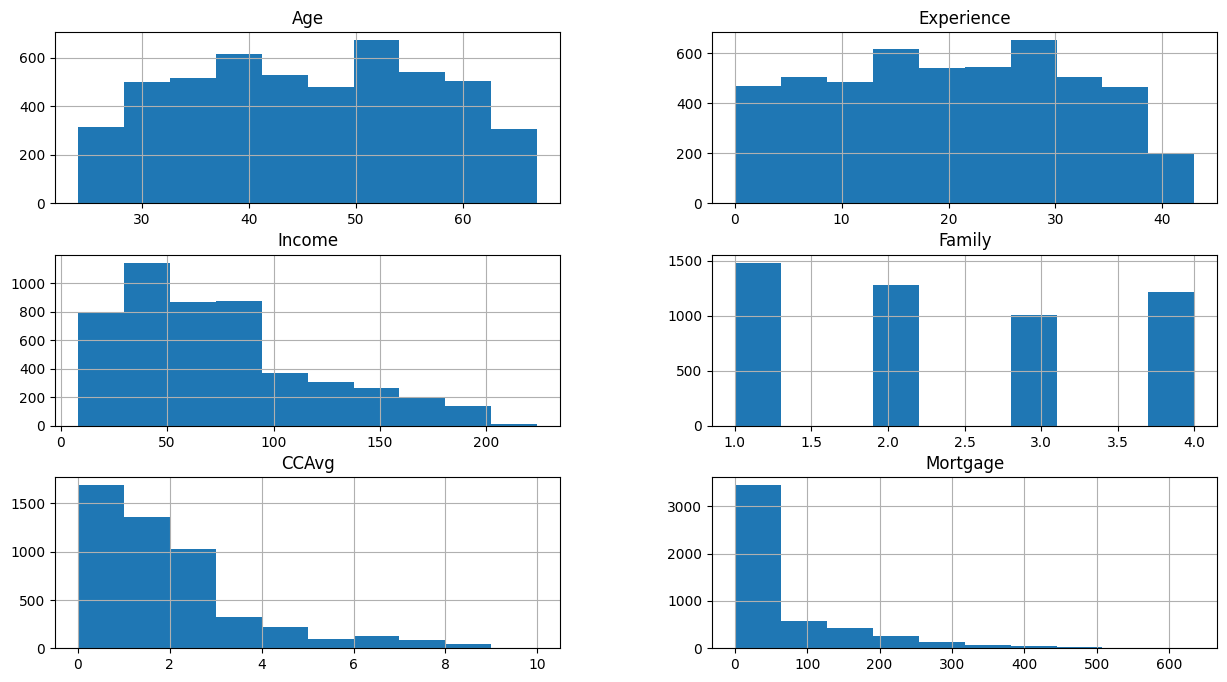

In [2299]:
#histogramas
loan_df[num_cols].hist(figsize=(15,8))
plt.show()

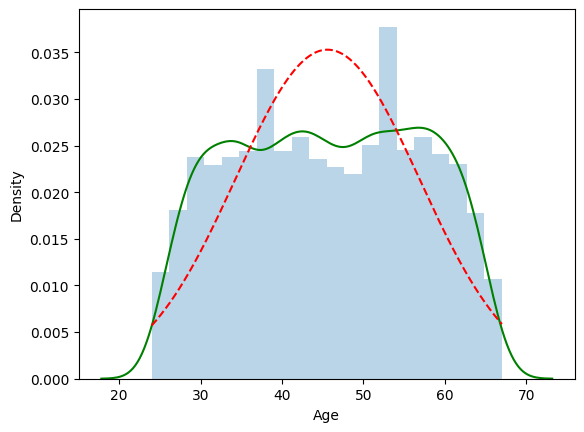

In [2300]:
#Age
plt.hist(loan_df['Age'], bins=20, density= True, alpha= 0.3)
sns.kdeplot(x=loan_df['Age'], color='green')

x_vals = np.linspace(loan_df['Age'].min(), loan_df['Age'].max(), 1000)
normal_ref = norm.pdf(x_vals, loc= loan_df['Age'].mean(), scale= loan_df['Age'].std())
plt.plot(x_vals, normal_ref, color='red', linestyle='--')


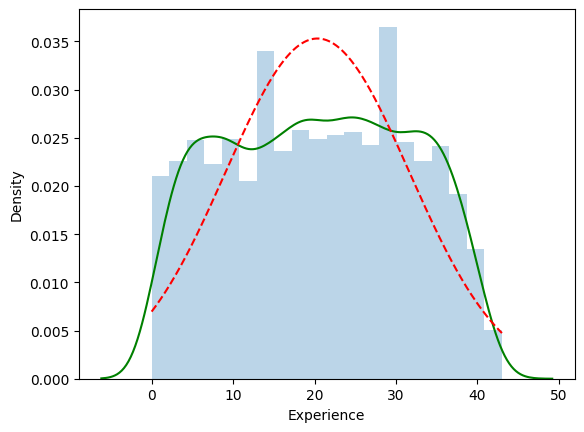

In [2301]:
#Experience
plt.hist(loan_df['Experience'], bins=20, density= True, alpha= 0.3)
sns.kdeplot(x=loan_df['Experience'], color='green')

x_vals = np.linspace(loan_df['Experience'].min(), loan_df['Experience'].max(), 1000)
normal_ref = norm.pdf(x_vals, loc= loan_df['Experience'].mean(), scale= loan_df['Experience'].std())
plt.plot(x_vals, normal_ref, color='red', linestyle='--')

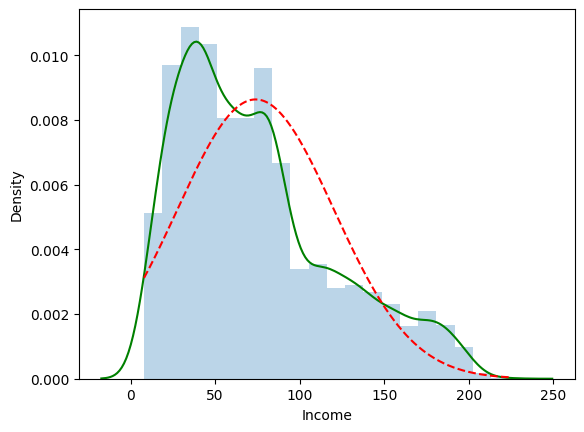

In [2302]:
#Income
plt.hist(loan_df['Income'], bins=20, density= True, alpha= 0.3)
sns.kdeplot(x=loan_df['Income'], color='green')

x_vals = np.linspace(loan_df['Income'].min(), loan_df['Income'].max(), 1000)
normal_ref = norm.pdf(x_vals, loc= loan_df['Income'].mean(), scale= loan_df['Income'].std())
plt.plot(x_vals, normal_ref, color='red', linestyle='--')

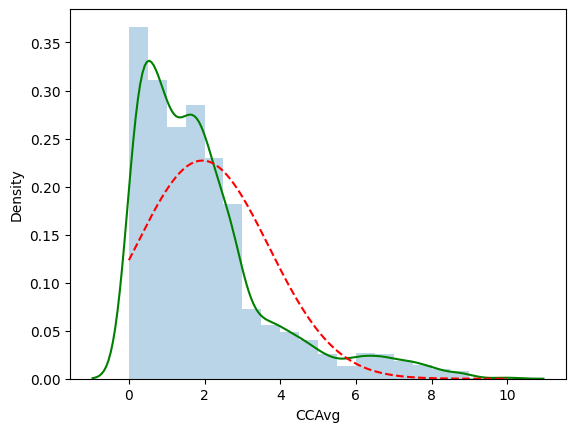

In [2303]:
#CCAvg
plt.hist(loan_df['CCAvg'], bins=20, density= True, alpha= 0.3)
sns.kdeplot(x=loan_df['CCAvg'], color='green')

x_vals = np.linspace(loan_df['CCAvg'].min(), loan_df['CCAvg'].max(), 1000)
normal_ref = norm.pdf(x_vals, loc= loan_df['CCAvg'].mean(), scale= loan_df['CCAvg'].std())
plt.plot(x_vals, normal_ref, color='red', linestyle='--')

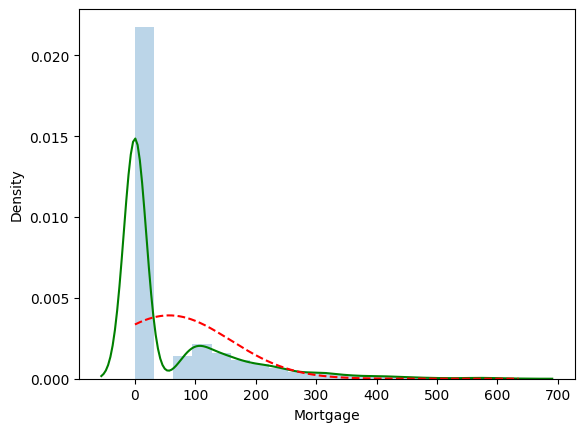

In [2304]:
#Mortgage
plt.hist(loan_df['Mortgage'], bins=20, density= True, alpha= 0.3)
sns.kdeplot(x=loan_df['Mortgage'], color='green')

x_vals = np.linspace(loan_df['Mortgage'].min(), loan_df['Mortgage'].max(), 1000)
normal_ref = norm.pdf(x_vals, loc= loan_df['Mortgage'].mean(), scale= loan_df['Mortgage'].std())
plt.plot(x_vals, normal_ref, color='red', linestyle='--')

Los valores númericos de curtosis y simetria coinciden con lo mostrado en las visualizaciones de las variables.

<BarContainer object of 4 artists>

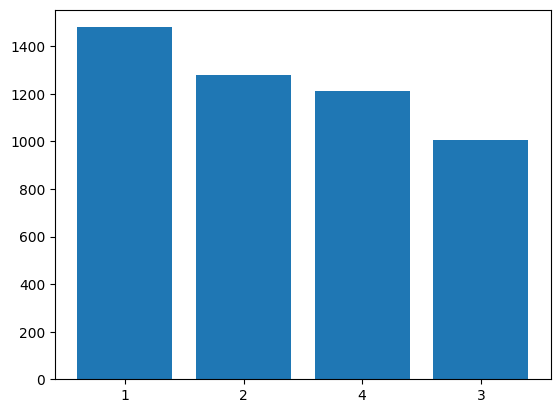

In [2305]:
#Family, debido a la naturaleza de la variable y los valores que puede tomar, no tendria sentido generar una grafica de campana
counts = loan_df['Family'].value_counts()
plt.bar(counts.index.astype(str), counts.values)

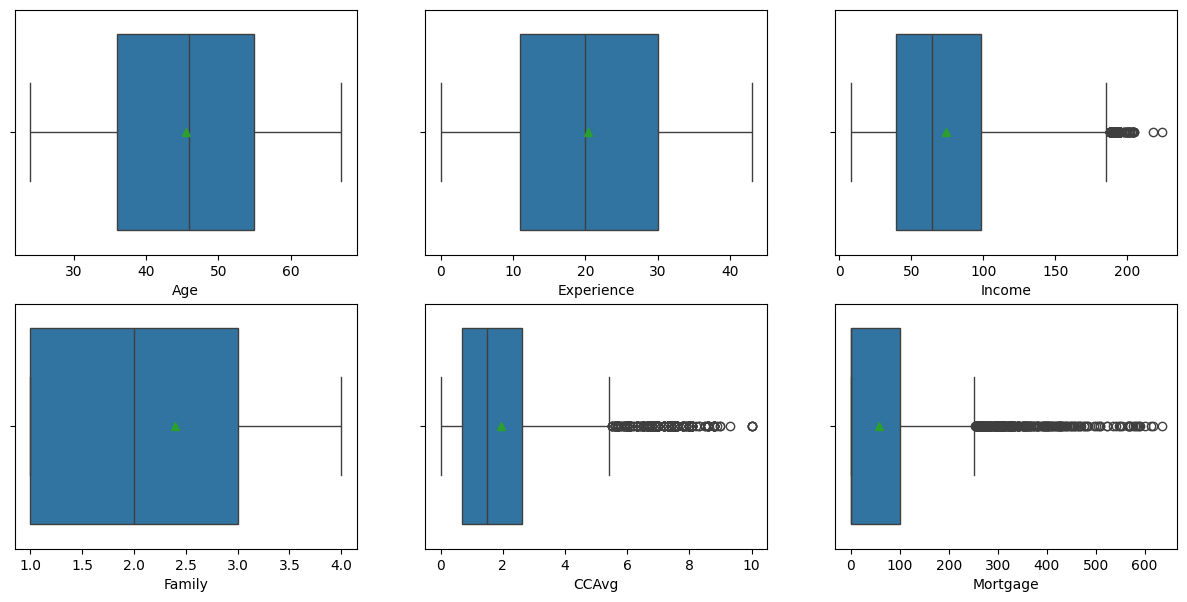

In [2306]:
#boxplot para las variables
fig, axes = plt.subplots(2,3, figsize=(15,7))
axes = axes.ravel()
for col, ax in zip(loan_df[num_cols], axes):
  sns.boxplot(x=loan_df[col], ax=ax, showmeans=True)
  ax.set(xlabel=f'{col}')

Para las variables Age y Experience, el boxplot muestra que la media y la mediana estan muy cerca, por lo que, la curva seria aproximadamente simetrica. En cuanto a las otras variables, se observa que las curvas presentarán asimetría.

8. Obtén las estadísticas descriptivas de las variables categóricas.
* Genera un gráfico de barras para cada variable. En las de alta cardinalidad, sólo incluye los 10 valores más relevantes.

<BarContainer object of 10 artists>

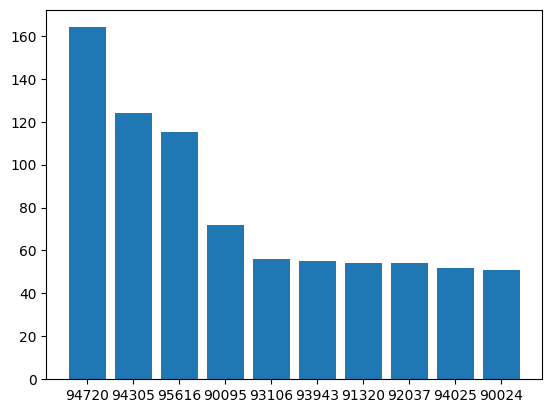

In [2307]:
counts = loan_df['ZIP Code'].value_counts()
top_10 = counts.head(10)
plt.bar(top_10.index.astype(str), top_10.values)

<BarContainer object of 3 artists>

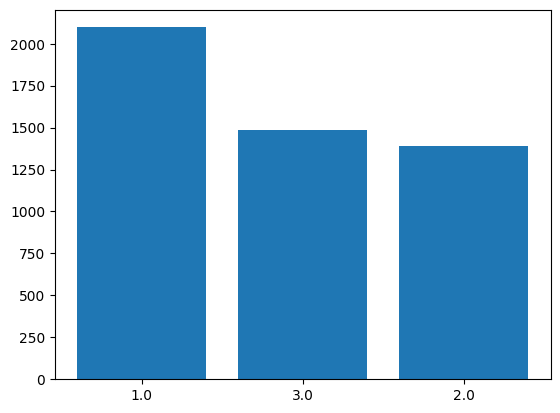

In [2308]:
#Education
counts = loan_df['Education'].value_counts()
plt.bar(counts.index.astype(str), counts.values)

<BarContainer object of 2 artists>

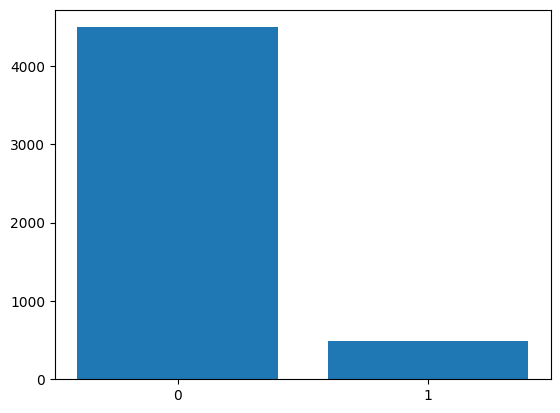

In [2309]:
#Personal Loan
counts = loan_df['Personal Loan'].value_counts()
plt.bar(counts.index.astype(str), counts.values)

<BarContainer object of 2 artists>

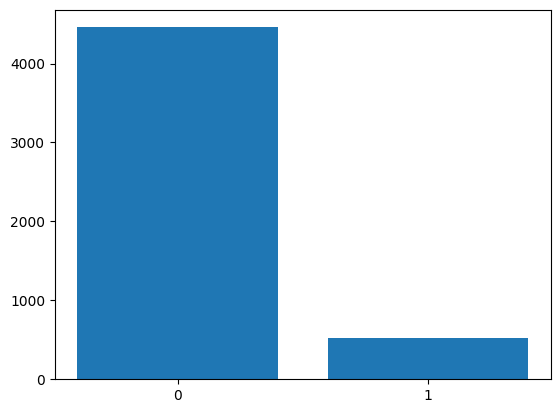

In [2310]:
#Securities Account
counts = loan_df['Securities Account'].value_counts()
plt.bar(counts.index.astype(str), counts.values)

<BarContainer object of 2 artists>

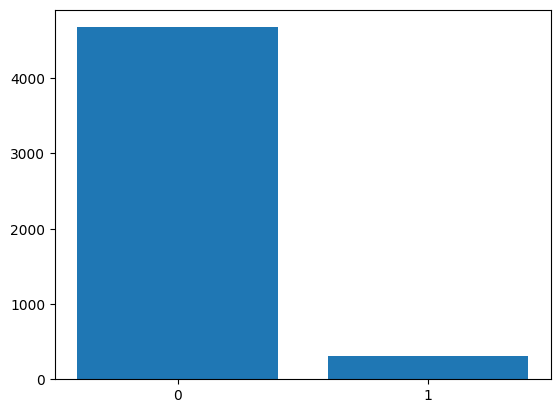

In [2311]:
#CD Account
counts = loan_df['CD Account'].value_counts()
plt.bar(counts.index.astype(str), counts.values)

<BarContainer object of 2 artists>

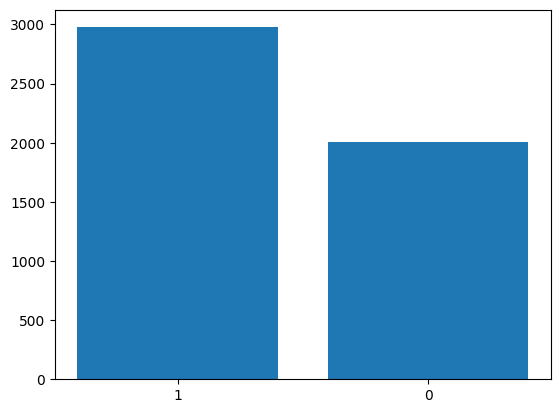

In [2312]:
#Online
counts = loan_df['Online'].value_counts()
plt.bar(counts.index.astype(str), counts.values)

<BarContainer object of 2 artists>

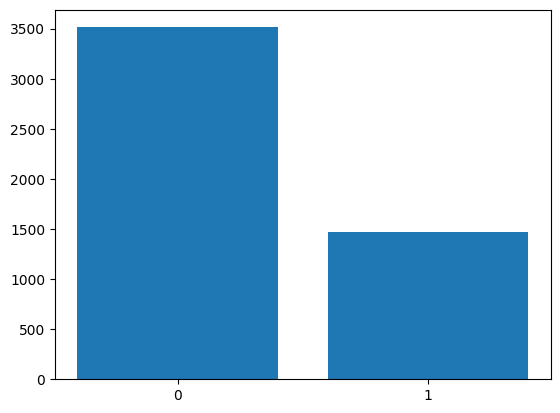

In [2313]:
#CreditCard
counts = loan_df['CreditCard'].value_counts()
plt.bar(counts.index.astype(str), counts.values)

# Análisis exploratorio de datos (bivariado)

9. Obtén la matriz de gráficos de dispersión (*scatter matrix*) de todas las variables numéricas.
* Observa las relaciones entre las variables, selecciona un par representativo y describe los patrones o tendencias que sean evidentes.
* Para cuantificar la fuerza y dirección de las relaciones observadas, genera un mapa de calor con los valores de correlación de *Pearson*. ¿El valor numérico obtenido del par seleccionado se corresponde con lo esperado?

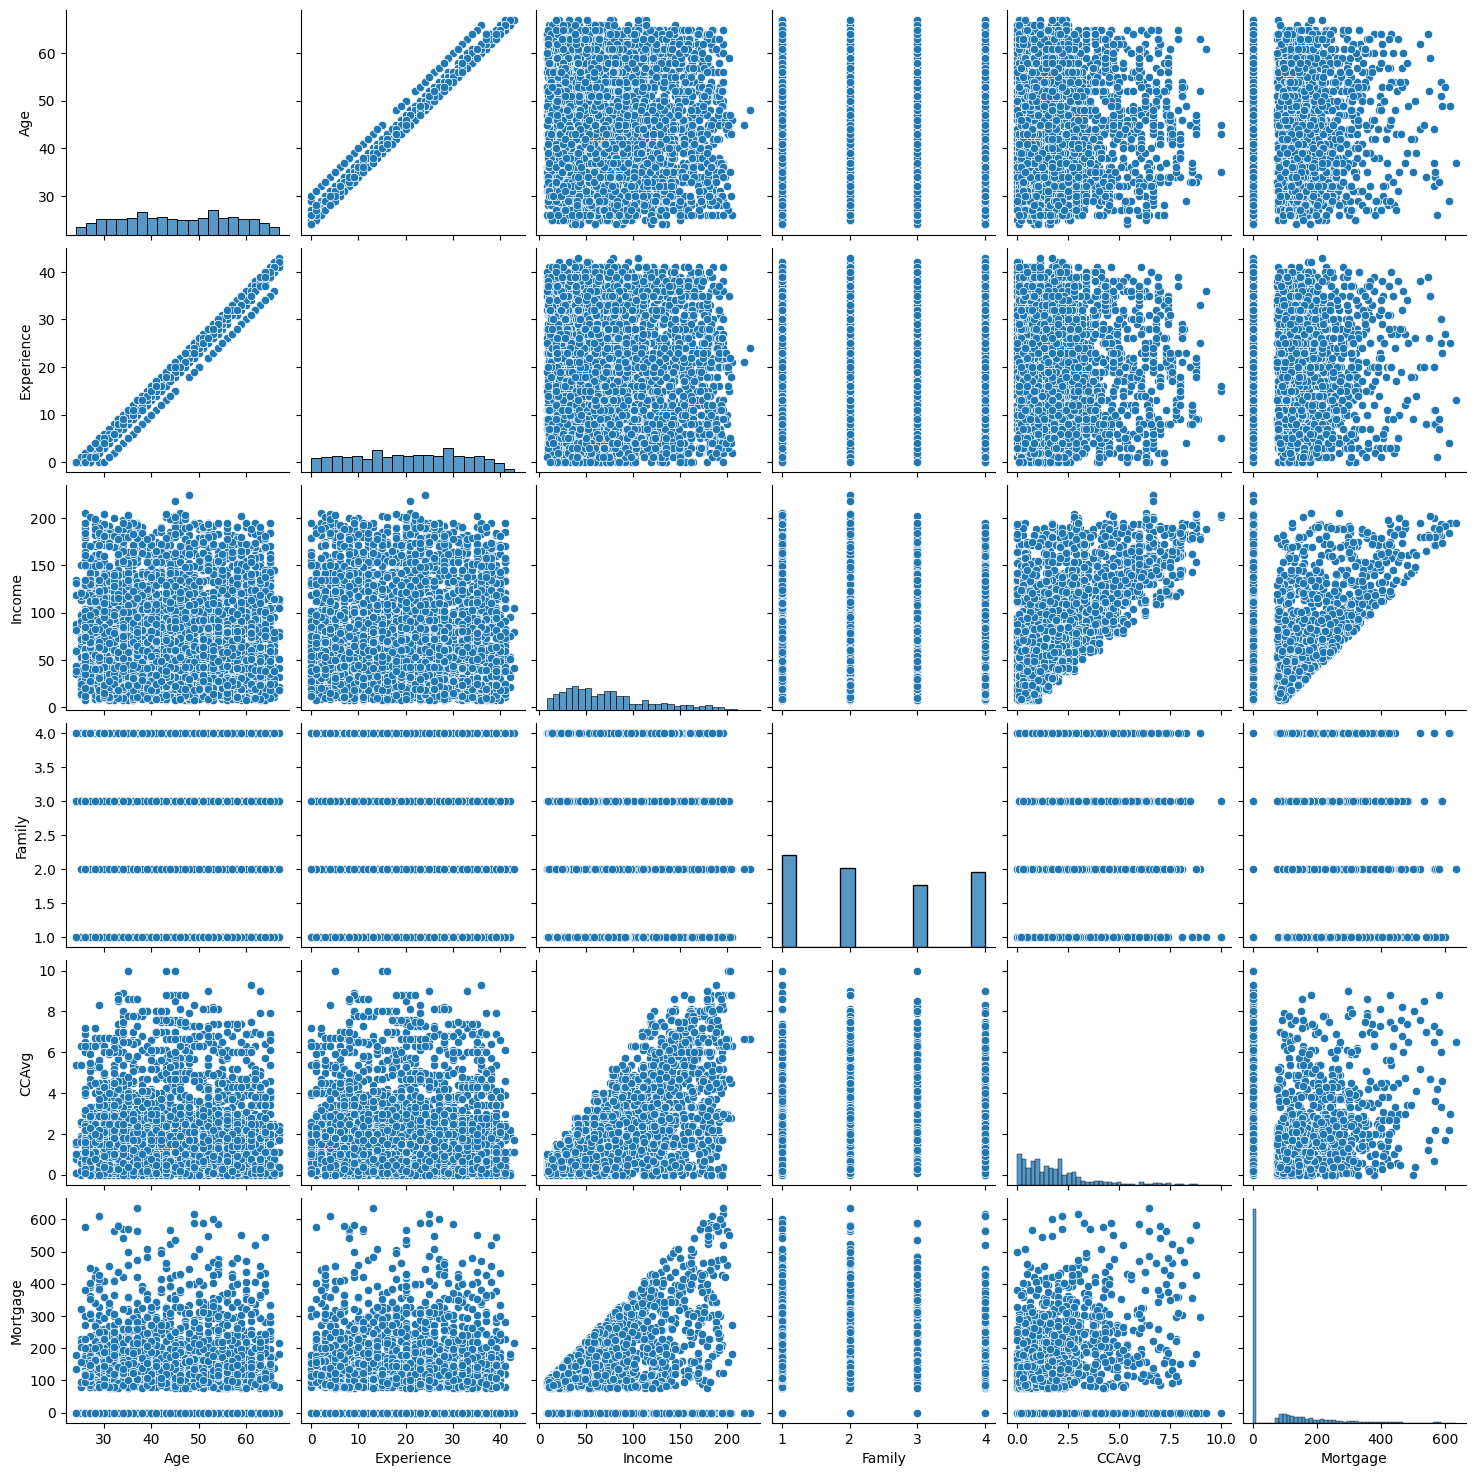

In [2314]:
num_var_df = loan_df[num_cols]
sns.pairplot(num_var_df)

La relación más marcada es la edad respecto a la experiencia. Lo cual tiene sentido, a mayor edad más años de experiencia tiene una persona. Por otro lado, existe una relación entre el valor de la hipoteca y el ingreso, podriamos intuir que a mayores ingresos mayor será el monto de la hipoteca.

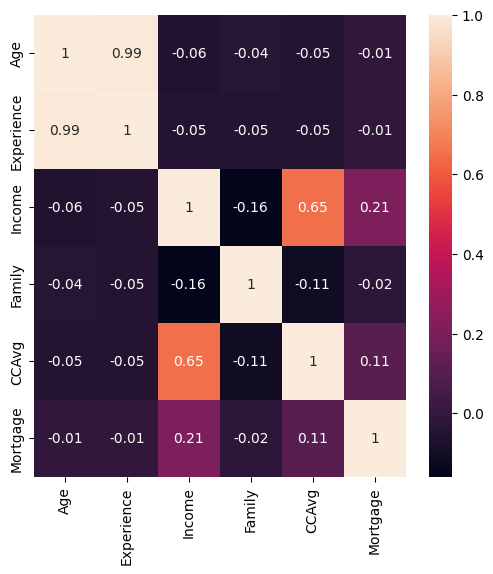

In [2315]:
plt.figure(figsize = (6, 6))
sns.heatmap(round(loan_df.corr(numeric_only=True),2), annot = True)
plt.show()

Podemos ver que, númericamente, se cumple la correlación entre la Edad y la Experiencia, siendo una correlación casi perfecta. En cuanto a los ingresos y el valor de la hipoteca, la correlación no es tan fuerte.

10. Realiza un análisis de todas las variables del dataset con respecto a la variable de salida `Personal Loan`.
* Variables numéricas: Genera box plots para comparar la distribución de cada variable según los valores de `Personal Loan`.
* Variables categóricas (sin considerar `ZIP Code`): Genera gráficos de barras apiladas que muestren la distribución relativa de `Personal Loan` dentro de cada categoría de la variable.
* Para cada grupo de variables (numéricas y categóricas), comenta al menos un hallazgo o patrón relevante observado en los gráficos generados.


<Axes: xlabel='Age', ylabel='Personal Loan'>

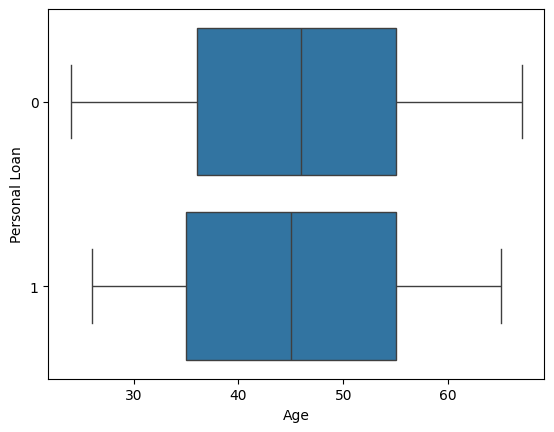

In [2316]:
#'Age'
sns.boxplot(x='Age',y='Personal Loan',data=loan_df)

<Axes: xlabel='Experience', ylabel='Personal Loan'>

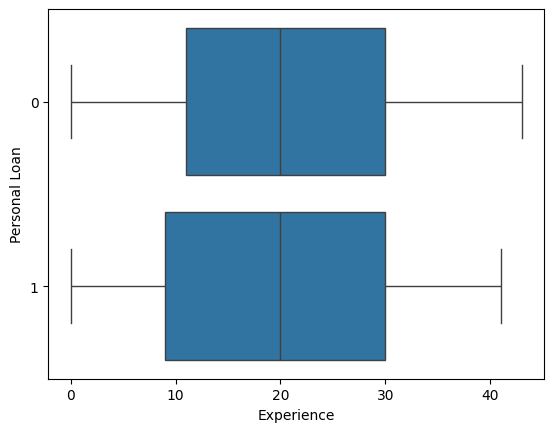

In [2317]:
#'Experience'
sns.boxplot(x='Experience',y='Personal Loan',data=loan_df)

<Axes: xlabel='Income', ylabel='Personal Loan'>

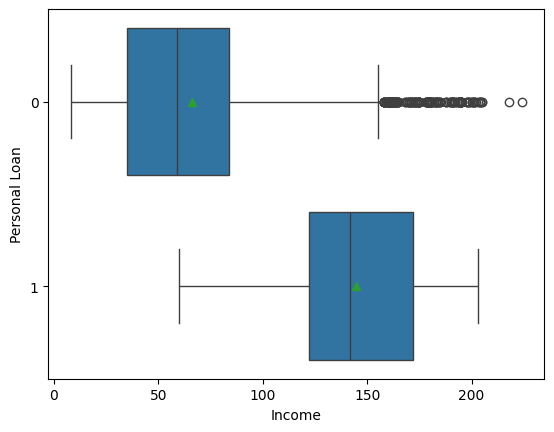

In [2318]:
#'Income'
sns.boxplot(x='Income',y='Personal Loan',data=loan_df, showmeans=True)

**HALLAZGO:**
Podemos observar, que la mayoría de personas que poseen un prestamo presentan ingresos altos, en promedio arriba de 150K dolares.

<Axes: xlabel='Family', ylabel='Personal Loan'>

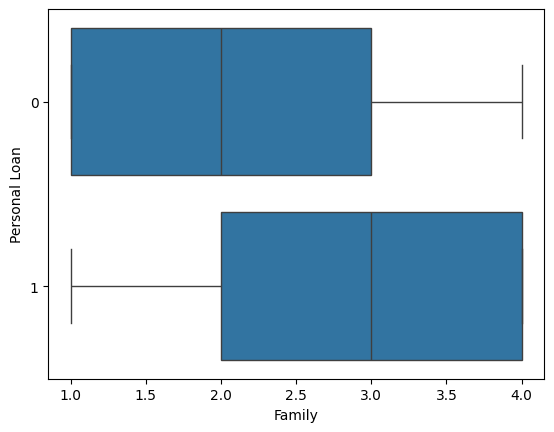

In [2319]:
#'Family'
sns.boxplot(x='Family',y='Personal Loan',data=loan_df)

<Axes: xlabel='CCAvg', ylabel='Personal Loan'>

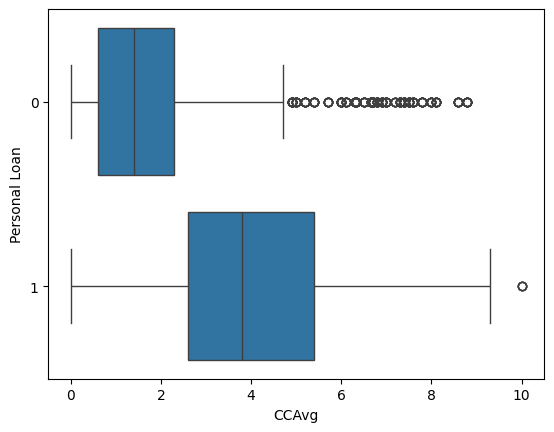

In [2320]:
#'CCAvg'
sns.boxplot(x='CCAvg',y='Personal Loan',data=loan_df)

<Axes: xlabel='Mortgage', ylabel='Personal Loan'>

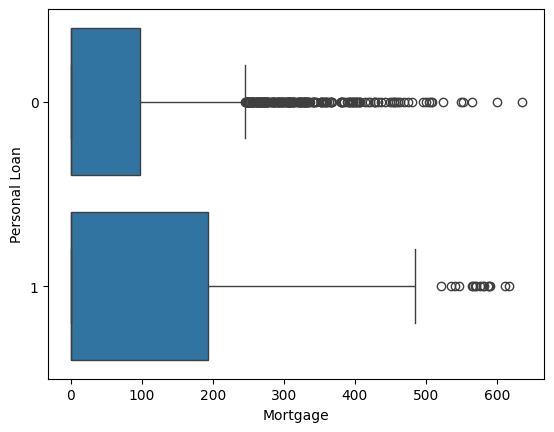

In [2321]:
#'Mortgage'
sns.boxplot(x='Mortgage',y='Personal Loan',data=loan_df)

<Axes: xlabel='Personal Loan'>

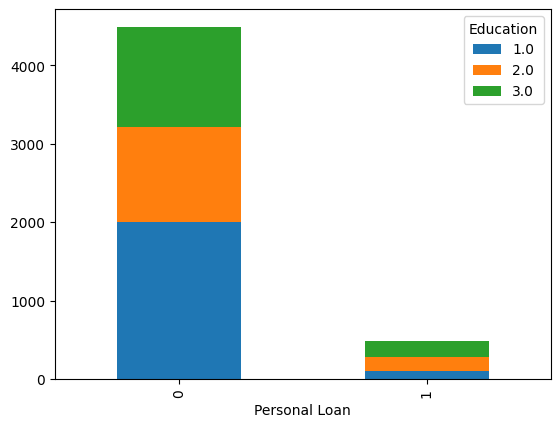

In [2322]:
#'Education'
contingency_tab = pd.crosstab(loan_df['Personal Loan'], loan_df['Education'])
contingency_tab.plot(kind='bar', stacked=True)

<Axes: xlabel='Personal Loan'>

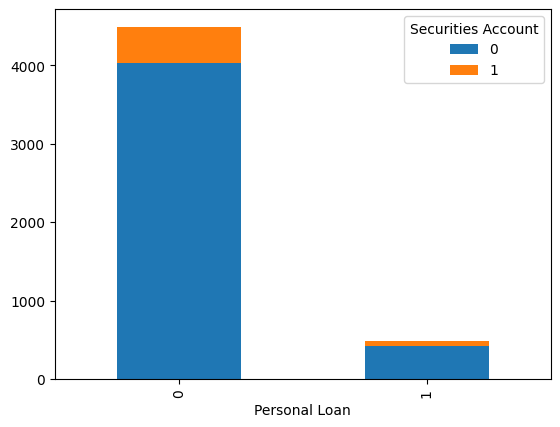

In [2323]:
#'Securities Account'
contingency_tab = pd.crosstab(loan_df['Personal Loan'], loan_df['Securities Account'])
contingency_tab.plot(kind='bar', stacked=True)

<Axes: xlabel='Personal Loan'>

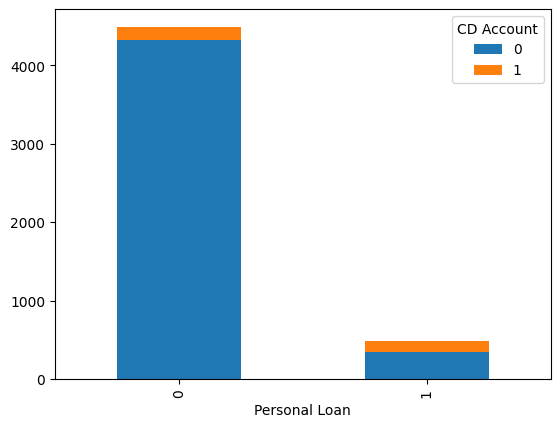

In [2324]:
#'CD Account'
contingency_tab = pd.crosstab(loan_df['Personal Loan'], loan_df['CD Account'])
contingency_tab.plot(kind='bar', stacked=True)

<Axes: xlabel='Personal Loan'>

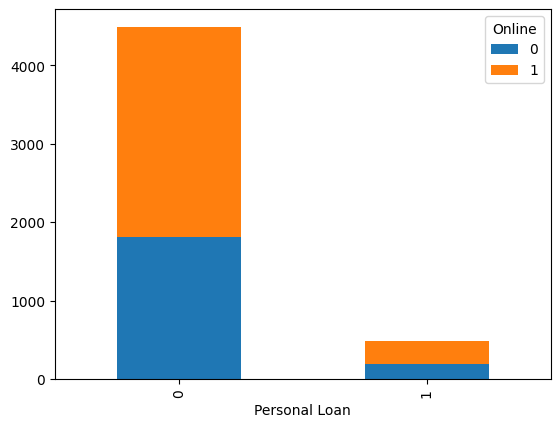

In [2325]:
#'Online'
contingency_tab = pd.crosstab(loan_df['Personal Loan'], loan_df['Online'])
contingency_tab.plot(kind='bar', stacked=True)

<Axes: xlabel='Personal Loan'>

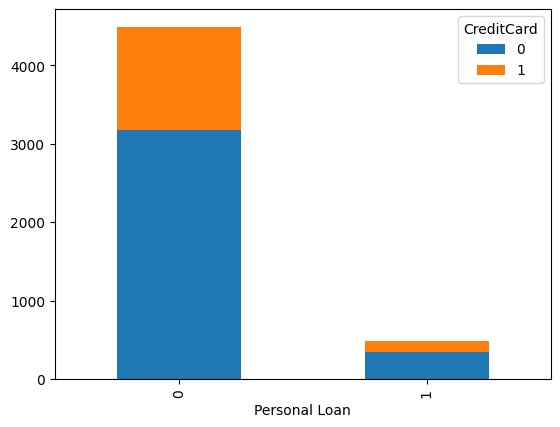

In [2326]:
#'CreditCard'
contingency_tab = pd.crosstab(loan_df['Personal Loan'], loan_df['CreditCard'])
contingency_tab.plot(kind='bar', stacked=True)

**HALLAZGO:** La mayoría de personas que no poseen una tarjeta de crédito tampoco tienen un prestamo personal.